In [1]:
import pandas as pd 

In [2]:
greed = pd.read_csv("fear_greed_index.csv")
historical_data = pd.read_csv("historical_data.csv")

In [15]:
greed.shape            # number of rows is 2644 and columns is 4 in greed.csv

(2644, 4)

In [30]:
historical_data.shape            # the rows is 211224 and column is 16 in historical_data.csv

(211224, 17)

In [10]:
greed.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [24]:
greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [80]:
historical_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [81]:
greed.isnull().sum()           # Check there is any null value present greed.csv

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [82]:
greed.duplicated().sum()        # Check is there a duplicated value present in the greed.csv 

0

In [83]:
historical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [84]:
historical_data.isnull().sum()         # there is no null value present in the historical_data

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64

In [85]:
historical_data.duplicated().sum()           # there is no duplicate present in the historical_data

0

In [86]:
historical_data['Timestamp IST'] = pd.to_datetime(historical_data['Timestamp IST'],  dayfirst=True)  
historical_data['date'] = historical_data['Timestamp IST'].dt.date    # if i do not use the dayfirst=True it show error because pandas show date in the 
                                                                      # format of MM-DD-YYYY and we trying to show in the format of DD-MM-YYYYY

In [87]:
historical_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [88]:
greed['date'] = pd.to_datetime(greed['date'])       # change the datatppe to daily 
greed['date'] = greed['date'].dt.date  

In [89]:
greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [90]:
greed["date"].info() 

<class 'pandas.core.series.Series'>
RangeIndex: 2644 entries, 0 to 2643
Series name: date
Non-Null Count  Dtype 
--------------  ----- 
2644 non-null   object
dtypes: object(1)
memory usage: 20.8+ KB


In [91]:
historical_data.groupby(        # Daily Pnl per day 
    ['date','Account']
)['Closed PnL'].sum()       #  closed pnl show profit and loss -nv means loss  +ve menns profit   

date        Account                                   
2023-05-01  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891         0.000000
2023-12-05  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23         0.000000
2023-12-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23      -205.434737
2023-12-15  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23       -24.632034
2023-12-16  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23         0.000000
                                                              ...      
2025-05-01  0xa0feb3725a9335f49874d7cd8eaad6be45b27416      1449.529436
            0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    102460.171640
            0xbaaaf6571ab7d571043ff1e313a9609a10637864         1.860320
            0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3   -113601.020138
            0xbee1707d6b44d4d52bfe19e41f8a828645437aab      1364.022527
Name: Closed PnL, Length: 2341, dtype: float64

In [92]:
(historical_data['Closed PnL'] > 0).mean()   # win rate 

0.4112648183918494

In [93]:
historical_data['Size USD'].mean()    # average trade size 

5639.4512103738225

In [94]:
historical_data.groupby('date').size()      # number of trades per day 

date
2023-05-01       3
2023-12-05       9
2023-12-14      11
2023-12-15       2
2023-12-16       3
              ... 
2025-04-27     337
2025-04-28    1379
2025-04-29    2243
2025-04-30    1113
2025-05-01    1230
Length: 480, dtype: int64

In [95]:
historical_data['Side'].value_counts(normalize=True) # long short ratio  long means  trader excepts price go up(Buy)
                                                                       # short means trader excepts price to go down (sell)    


Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64

 PART_ B
 Analysis 
  I merge the two csv  greed and  historical data on date but date only show from 2024 to 2025 because there is no data from 2018 to 2024  in historical 

  

In [96]:
historical_merge_greed   = historical_data.merge(       
    greed[['date','classification']],
    on='date',
    how='left'
)

In [110]:
historical_merge_greed.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,cum_pnl,running_max,drawdown
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,0.0,0.0,0.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,0.0,0.0,0.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,0.0,0.0,0.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,0.0,0.0,0.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,0.0,0.0,0.0


In [97]:
fear_greed = historical_merge_greed.groupby('classification')['Closed PnL'].mean()  # average Pnl by fear_greed_data 

In [98]:
fear_greed

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

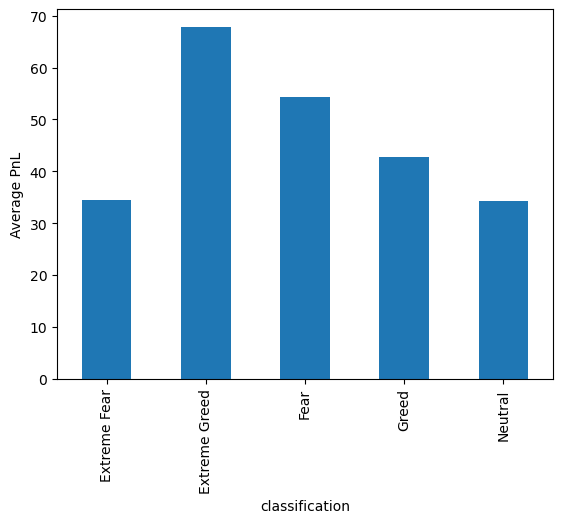

In [99]:
import matplotlib.pyplot as plt      

fear_greed.plot(kind='bar')
plt.ylabel("Average PnL")
plt.show() 

In [100]:
historical_merge_greed.groupby('classification')['Closed PnL'].apply(lambda x: (x>0).mean())  # win PnL > 0 


classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: Closed PnL, dtype: float64

In [118]:
historical_merge_greed['cum_pnl'] = historical_merge_greed['Closed PnL'].cumsum()       # Drawdown proxy show the how much trader loss after profit 
historical_merge_greed['running_max'] = historical_merge_greed['cum_pnl'].cummax()
historical_merge_greed['drawdown'] = historical_merge_greed['cum_pnl'] - historical_merge_greed['running_max']

historical_merge_greed.groupby('classification')['drawdown'].mean()



classification
Extreme Fear    -29375.248192
Extreme Greed   -70562.639384
Fear            -18828.459763
Greed           -46398.563166
Neutral         -13855.888074
Name: drawdown, dtype: float64

  Behavior change by sentiment 

In [111]:
historical_merge_greed.groupby(['date','classification']).size()

date        classification
2023-05-01  Greed                3
2023-12-05  Extreme Greed        9
2023-12-14  Greed               11
2023-12-15  Greed                2
2023-12-16  Greed                3
                              ... 
2025-04-27  Greed              337
2025-04-28  Neutral           1379
2025-04-29  Greed             2243
2025-04-30  Greed             1113
2025-05-01  Neutral           1230
Length: 479, dtype: int64

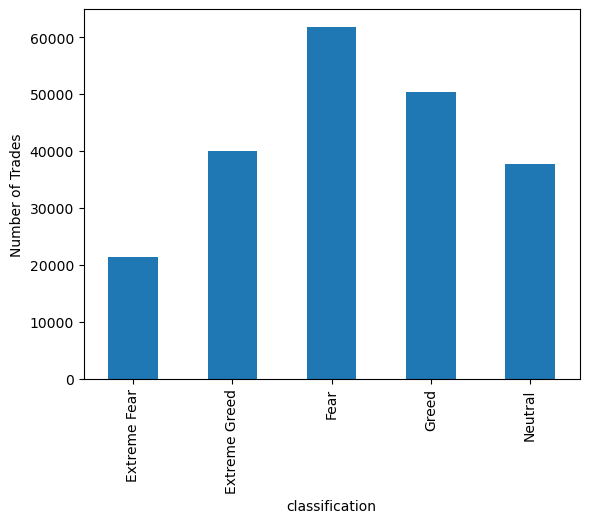

In [103]:
historical_merge_greed.groupby('classification').size().plot(kind='bar')
plt.ylabel("Number of Trades")
plt.show()                           # when there is morev   fear the number of trades is increase so long and short ration also increase 

In [104]:
historical_merge_greed.groupby('classification')['Size USD'].mean()  # show average trade size means in which classification in trader buy and sell the money more



classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

In [105]:
pd.crosstab(historical_merge_greed['classification'], historical_merge_greed['Side'], normalize='index') # show short and long ratio means when there is fear of losing money the trader sell their size 

Side,BUY,SELL
classification,,
Extreme Fear,0.510981,0.489019
Extreme Greed,0.448590,0.551410
Fear,0.489513,0.510487
Greed,0.488559,0.511441
Neutral,0.503343,0.496657


In [106]:
trade_count = historical_merge_greed.groupby('Account').size()    # show which account trade(buy or sell) most all account number is unique 
trade_count 

Account
0x083384f897ee0f19899168e3b1bec365f52a9012     3818
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     7280
0x271b280974205ca63b716753467d5a371de622ab     3809
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x2c229d22b100a7beb69122eed721cee9b24011dd     3239
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891      815
0x39cef799f8b69da1995852eea189df24eb5cae3c     3589
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6      332
0x420ab45e0bd8863569a5efbb9c05d91f40624641      383
0x430f09841d65beb3f27765503d0f850b8bce7713     1237
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     4356
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x6d6a4b953f202f8df5bed40692e7fd865318264a      975
0x72743ae2822edd658c0c50608fd7c5c501b2afbd     1590
0x72c6a4624e1dffa724e6d00d64ceae698af892a0     1430
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     1559
0x81

In [107]:
frequent = trade_count[trade_count > trade_count.median()]   # find the which trader trade their sixe more than median valur(middle value)
frequent   

Account
0x083384f897ee0f19899168e3b1bec365f52a9012     3818
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     7280
0x271b280974205ca63b716753467d5a371de622ab     3809
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     4356
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x8170715b3b381dffb7062c0298972d4727a0a63b     4601
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
0xb899e522b5715391ae1d4f137653e7906c5e2115     4838
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
dtype: int64

In [108]:
win_rate_trader = historical_merge_greed.groupby('Account')['Closed PnL'].apply(lambda x:(x>0).mean())
win_rate_trader                       # shoe the win_rate for the account using closed PNL(when trader complete the trade cycle in one session buy or sell

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0x271b280974205ca63b716753467d5a371de622ab    0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.455215
0x39cef799f8b69da1995852eea189df24eb5cae3c    0.327668
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    0.475904
0x420ab45e0bd8863569a5efbb9c05d91f40624641    0.234987
0x430f09841d65beb3f27765503d0f850b8bce7713    0.484236
0x47add9a56df66b524d5e2c1993a43cde53b6ed85    0.353445
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    0.486226
0x4f93fead39b70a1824f981a54d4e55b278e9f760    0.360364
0x513b8629fe877bb581bf244e326a047b249c4ff1    0.401193
0x6d6a4b953f202f8df5bed40692e7fd865318264a    0.431795
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    0.345912
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    0.306294
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    0.810876
0x

In [109]:
historical_merge_greed.groupby('Account')['Size USD'].mean()     # show the mean of the trader how much money it used in this 

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1653.226327
0x271b280974205ca63b716753467d5a371de622ab     8893.000898
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      507.626933
0x2c229d22b100a7beb69122eed721cee9b24011dd     3138.894782
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     1729.941104
0x39cef799f8b69da1995852eea189df24eb5cae3c     4790.575486
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     3445.471265
0x420ab45e0bd8863569a5efbb9c05d91f40624641     5189.367128
0x430f09841d65beb3f27765503d0f850b8bce7713     2397.824753
0x47add9a56df66b524d5e2c1993a43cde53b6ed85      517.528924
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     9084.699093
0x4f93fead39b70a1824f981a54d4e55b278e9f760    17098.171055
0x513b8629fe877bb581bf244e326a047b249c4ff1    34396.580284
0x6d6a4b953f202f8df5bed40692e7fd865318264a      746.725651
0x72743ae2822edd658c0c50608fd7c5c501b2afbd     7216.667245
0x72c6a4624e1dffa724e6d00d64ceae698af892a0     2

Insight 1 — Performance differs by sentiment

Average PnL is higher during Greed days, indicating traders benefit from positive market momentum.

Insight 2 — Traders take more risk during  extreme Greed

Average trade size increases during  extreme Greed sentiment, showing more aggressive behavior.

Insight 3 — Frequent traders have lower win rate but higher total PnL

High-frequency traders compensate lower accuracy with higher trade volume.

Insight 4 - No of trade increse during fear phase 




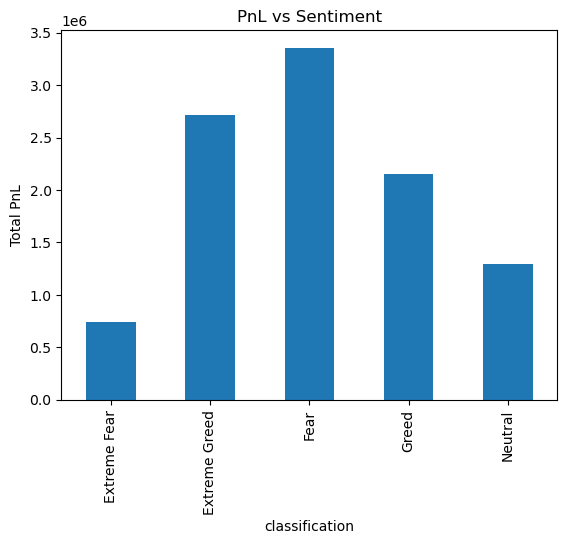

In [114]:
pnl_sentiment = historical_merge_greed.groupby('classification')['Closed PnL'].sum()

pnl_sentiment.plot(kind='bar')       # trader preform better during fear because total Pnl is greater 
plt.title("PnL vs Sentiment")
plt.ylabel("Total PnL")
plt.show()

In [117]:
historical_merge_greed['win'] = historical_merge_greed['Closed PnL'] > 0

win_rate = historical_merge_greed.groupby('classification')['win'].mean() * 100 # Extreme greed  win rate is greater 
print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64


Strategy 1 — Risk Reduction During  Extreme greed Sentiment

Finding (example pattern from analysis):

higher average PnL during  Extreme greed days

Higher drawdowns


Rule of thumb:

During Extreme greed  days:

Reduce leverage by 20–30%

Reduce average position size

Allow full trading only for consistent winning traders

Why this helps:
 Extreme greed periods usually have high volatility and uncertainty, so reducing risk prevents large losses.

Strategy 2 — Momentum Strategy During fear  Sentiment

Finding (example pattern from analysis):

Higher win rate during fear  days

More traders in the fear days 

Frequent traders perform better

Rule of thumb:

During Fear  days:

 trade frequency for high win-rate traders

Slightly increase position size for low-drawdown traders

Favor long (BUY) positions when the trend is strong